In [900]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [835]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [836]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
                    

In [837]:
tol = 1e-32

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

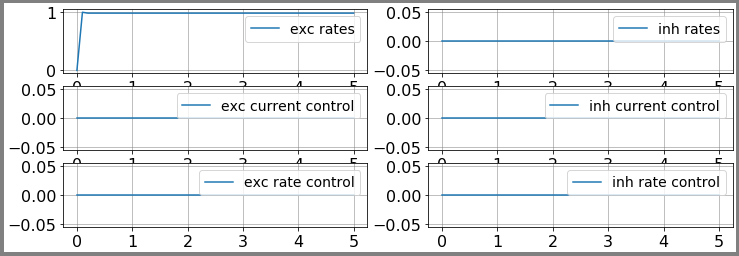

In [890]:
aln = RateModel()

aln.params['duration'] = 5.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

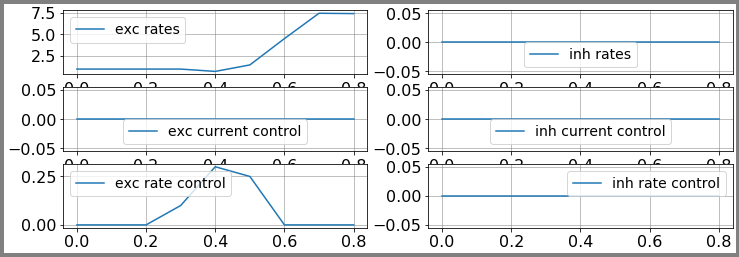

no delay : 
exc rates :  [0.98520605 0.98520605 0.98520605 0.98520605 0.71630386 1.46424479
 4.50635063 7.43573039 7.39820445]
inh rates :  [0. 0. 0. 0. 0. 0. 0. 0. 0.]
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[[0.98520605 0.98520605 0.98520605 0.71630386 1.46424479 4.50635063
   7.43573039 7.39820445]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]]]


In [933]:
dur = 0.7
dur_pre = 0.1
dur_post = 0.1

n_dur = int(dur/aln.params.dt + 1)
n_pre = int(dur_pre/aln.params.dt + 1)

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 5.
    min_cntrl = -5.
else:
    max_cntrl = 5.#0.5
    min_cntrl = -5.# 0.5

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    control0[0,j,n_pre + 1] = 0.02 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 2] = 0.06 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 3] = 0.05 * max_cntrl #- 0.0 * min_cntrl
    #control0[0,j,n_pre + 4] = 1.0 * max_cntrl - 0.2 * min_cntrl
    #control0[0,j,n_pre + 5] = 0.5 * max_cntrl - 0.6 * min_cntrl
    #control0[0,j,n_pre + 6] = 1.0 * max_cntrl - 0.8 * min_cntrl

#control0[0,1,:] = 0.    

setinitvars(high_state_vars)

aln.params.de = 0.
plotFunc.plot_traces(aln, control0)
print("no delay : ")
print("exc rates : ", aln.rates_exc[0,:])
print("inh rates : ", aln.rates_inh[0,:])

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]


control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-1):
    control1[0,j,k] += random.uniform(0., 1.) * max_cntrl

In [938]:
costparams = [1. * 1e0, 1.* 1e-3, 1.* 1e-3]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 100
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,3] += 0.01

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, 
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# 3.810394756896814

set cost params
RUN  0 , total integrated cost =  4.771802913974735
RUN  1 , total integrated cost =  0.7645495566697642
RUN  2 , total integrated cost =  0.11417139630784694
RUN  3 , total integrated cost =  0.03956181862318597
RUN  4 , total integrated cost =  0.03137529614040576
RUN  5 , total integrated cost =  0.015731336122129774
RUN  6 , total integrated cost =  0.011176116666331025
RUN  7 , total integrated cost =  0.009132822348350975
RUN  8 , total integrated cost =  0.006620423715085466
RUN  9 , total integrated cost =  0.0063302063696705725
RUN  10 , total integrated cost =  0.005044997103000419
RUN  11 , total integrated cost =  0.0039033796894771093
RUN  12 , total integrated cost =  0.003865107821124442
RUN  13 , total integrated cost =  0.0038181738596305666
RUN  14 , total integrated cost =  0.002948362592599449
RUN  15 , total integrated cost =  0.002620791660676111
RUN  16 , total integrated cost =  0.002594048976238668
RUN  17 , total integrated cost =  0.0004656446

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  70 , total integrated cost =  0.00013541542067712904
RUN  80 , total integrated cost =  0.00013541535215894152
RUN  90 , total integrated cost =  0.00013541533405163775
RUN  100 , total integrated cost =  0.00013541533181241509
Improved over  100  iterations by  99.99716217676519  percent.
Problem in initial value trasfer:  sigmae_f 0.0 0.9851996197764311
Problem in initial value trasfer:  sigmae_f 0.0 7.158520510058039
control ind  2
grad =  [1.04442806e-05 3.20519001e-05 1.53635227e-05 9.88464692e-06
 1.04769766e-05 1.04214750e-05 2.55386862e-05 0.00000000e+00]
best control =  [ 0.00000000e+00  1.73901476e-06  5.46127206e-06  9.99986902e-02
  2.99856234e-01  2.48623543e-01 -4.41705226e-03 -1.80832428e-02
  0.00000000e+00  0.00000000e+00]
total runtime =  0.5616930999967735


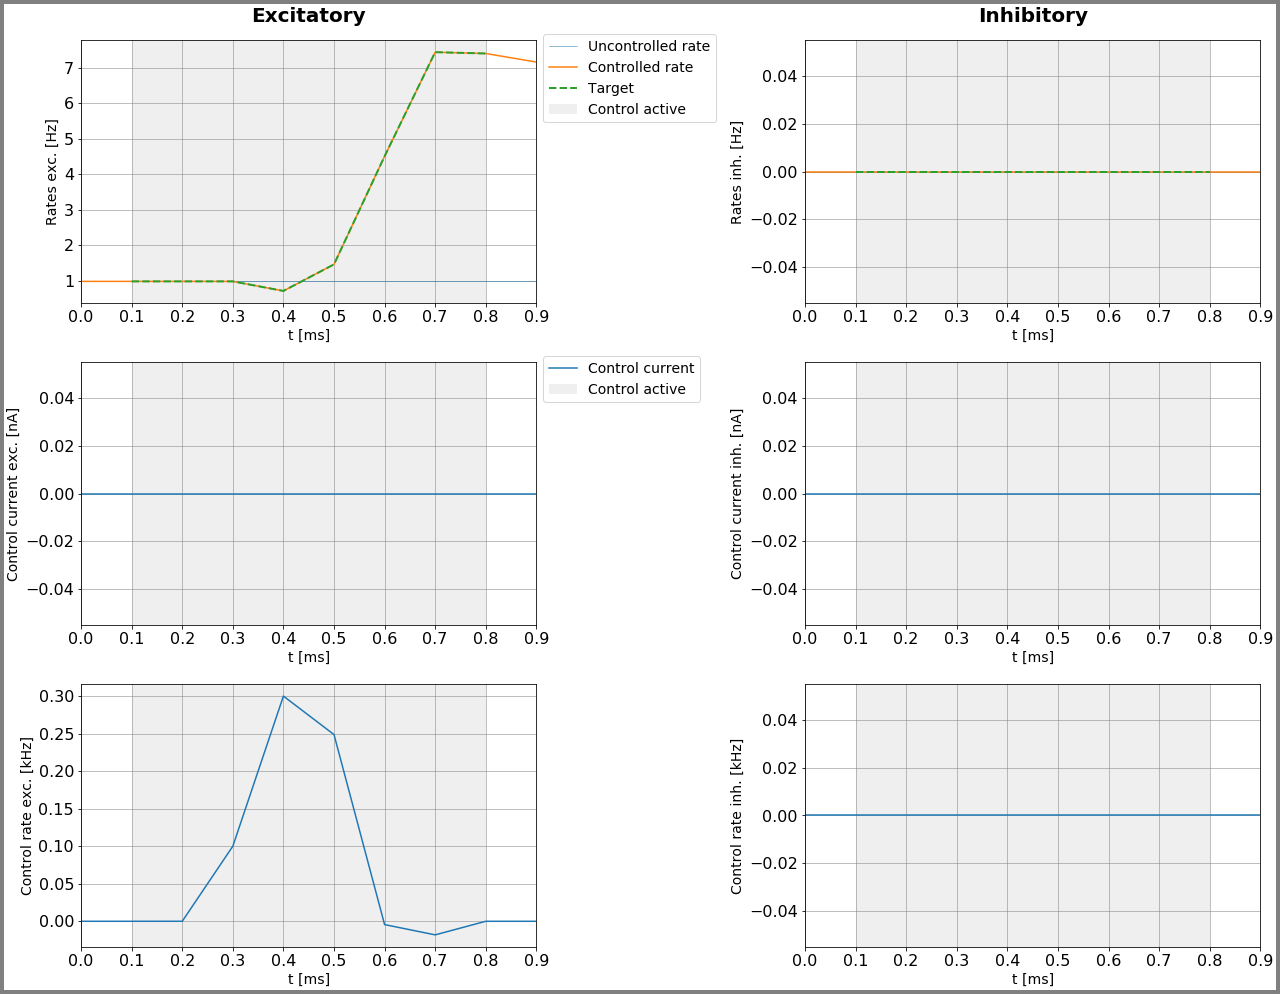

In [936]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

### Test cases

- [] precision only, c0-p0, no delay
- [] precision only, c0-p0, delay
- [] precision only, c0-p1, no delay
- [] precision only, c0-p1, delay
- [] precision only, c1-p1, no delay
- [] precision only, c1-p1, delay
- [] precision only, c1-p0, no delay
- [] precision only, c1-p0, delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p0, no delay
- [] precision only, c2-p1, delay
- [] precision only, c2-p1, delay

- [] p+e+s, c0-p0, no delay
- [] p+e+s, c0-p0, delay
- [] p+e+s, c0-p1, no delay
- [] p+e+s, c0-p1, delay
- [] p+e+s, c1-p1, no delay
- [] p+e+s, c1-p1, delay
- [] p+e+s, c1-p0, no delay
- [] p+e+s, c1-p0, delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p0, no delay
- [] p+e+s, c2-p1, delay
- [] p+e+s, c2-p1, delay

In [833]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
#control4 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]


print(max_cntrl, min_cntrl)

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control3, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)

set cost params
1.0 0.0
RUN  0 , total integrated cost:  5.952039202460933
RUN  1 , total integrated cost:  0.08203887342181887
RUN  2 , total integrated cost:  0.00021107802448258674
RUN  3 , total integrated cost:  6.628711077293317e-05
RUN  4 , total integrated cost:  3.9253662452426375e-05
State only changes marginally.
RUN  9 , total integrated cost:  3.858466241876079e-05
Improved over  9  iterations by  99.9993517404522  percent.


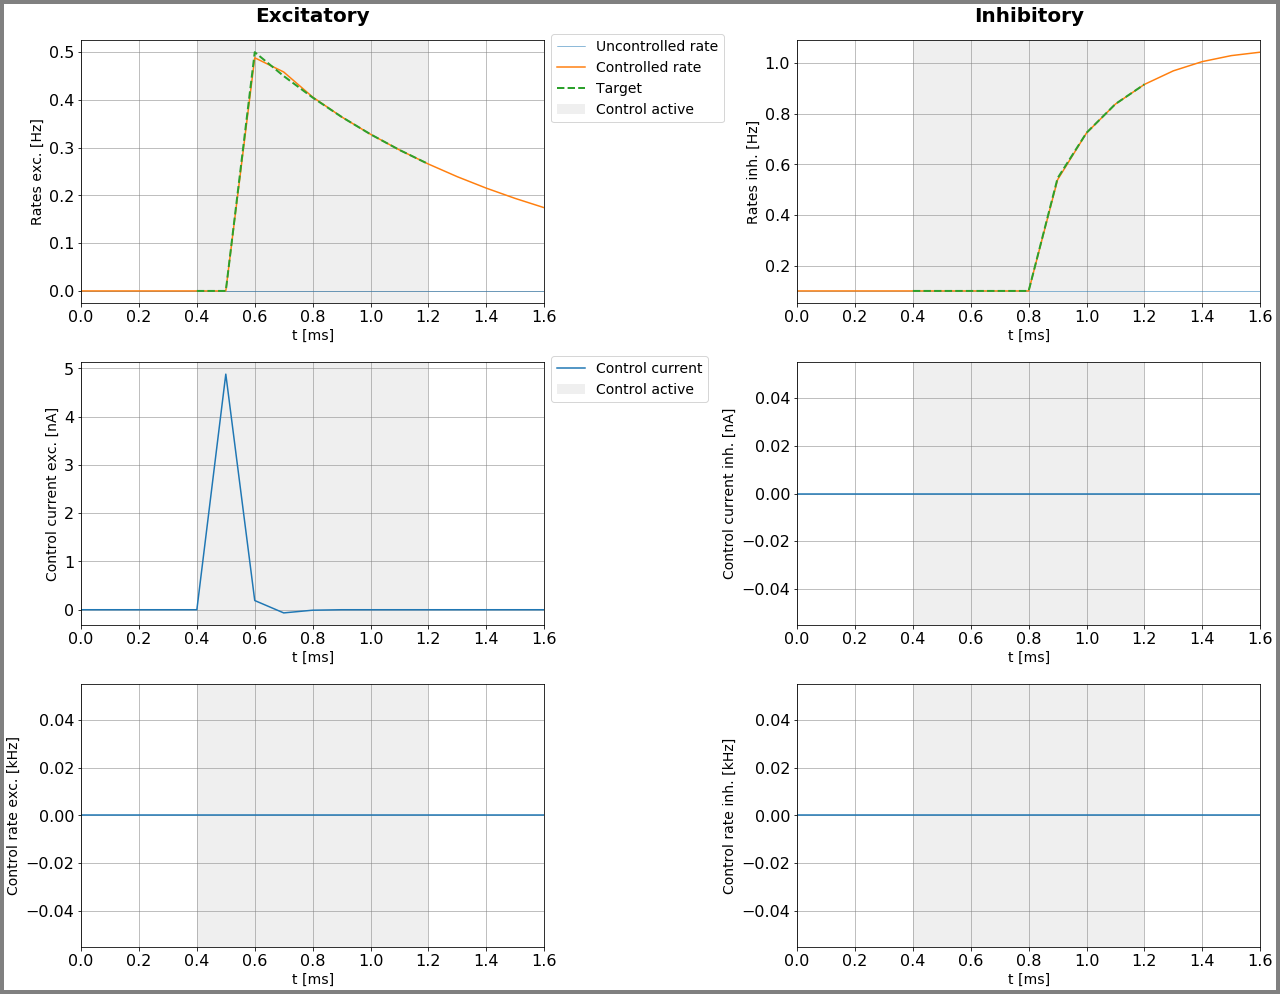

In [404]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

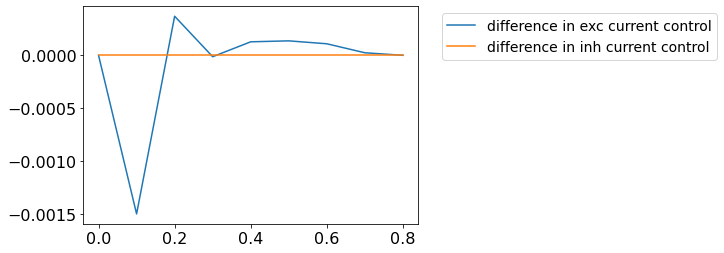

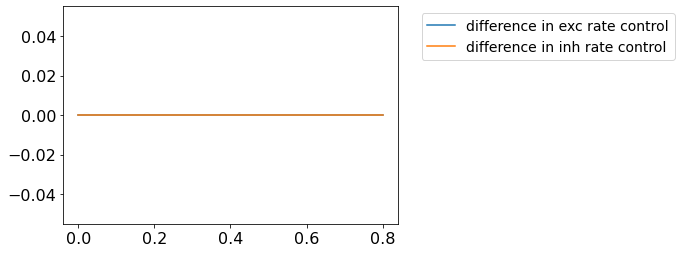

In [114]:
diff = bestControlA - bestControlA_A2
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,:], label="difference in exc current control")
plt.plot(t, diff[0,1,:], label="difference in inh current control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff[0,2,:], label="difference in exc rate control")
plt.plot(t, diff[0,3,:], label="difference in inh rate control")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.